https://www.youtube.com/watch?v=mCL2xLBDw8M&list=PLKnIA16_Rmvbr7zKYQuBfsVkjoLcJgxHH&index=36&t=1431s

# Arbitrary Value Imputation

**Definition**

Arbitrary Value Imputation is a missing value handling technique in which missing values are replaced with a fixed constant value (for example, `99`, `999`, or `-1`).

These values are chosen because they are outside the normal range of the data, making it easy for the machine learning model to recognize that the value was originally missing.

### When to Use
- When the data is **Not Missing Completely At Random (NMAR)**.
- When missing values themselves may contain useful information.

### Advantages
- Very simple and fast to implement.
- Preserves all rows in the dataset.
- Missing values become easily identifiable.

### Disadvantages
- Distorts the data distribution.
- Changes variance and covariance.
- Introduces artificial outliers.
- May reduce model performance if the arbitrary value is not chosen carefully.

> **Note:** This technique is less commonly used because it can significantly distort the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('titanic_toy.csv')

df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


# Check Missing Values

Identify the percentage of missing values in each column.

In [3]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


# Separate Features and Target

Split the dataset into input features (`X`) and the target variable (`y`).

In [4]:
X = df.drop(columns=['Survived'])
y = df['Survived']

# Split the Dataset

Split the data into training and testing sets.

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# Perform Arbitrary Value Imputation Using Pandas

Replace missing values in **Age** with **99** and **-1**, and replace missing values in **Fare** with **999** and **-1**.

New columns are created so that the original columns remain unchanged.

In [6]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

# Compare Variance

Compare the variance of the original and imputed columns to observe how arbitrary value imputation changes the spread of the data.

In [7]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after 99 wala imputation: ', X_train['Age_99'].var())
print('Age Variance after -1 wala imputation: ', X_train['Age_minus1'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after 999 wala imputation: ', X_train['Fare_999'].var())
print('Fare Variance after -1 wala imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  204.3495133904614
Age Variance after 99 wala imputation:  951.7275570187172
Age Variance after -1 wala imputation:  318.0896202624484
Original Fare variable variance:  2448.197913706318
Fare Variance after 999 wala imputation:  47219.20265217623
Fare Variance after -1 wala imputation:  2378.5676784883503


# Compare Age Distribution

Plot the original and imputed Age distributions to observe the effect of arbitrary value imputation.

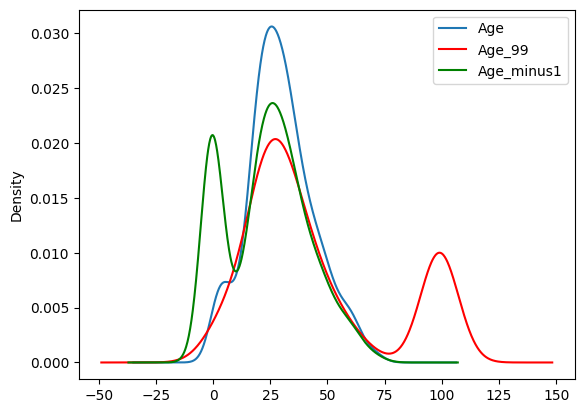

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with 99
X_train['Age_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with -1
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

## Note:
same for fare,also calculate covariance,corelations

# Apply Arbitrary Value Imputation Using Scikit-learn

Split the dataset again before applying Scikit-learn transformers.

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# Create Constant Imputers

Create two `SimpleImputer` objects that replace missing values with constant values.

In [10]:
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

# Create a Column Transformer

Apply constant value imputation to the **Age** and **Fare** columns while keeping the remaining columns unchanged.

In [11]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

# Train the Transformer

Fit the transformer on the training dataset.

In [12]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

# Check Learned Constant Value for Age

Display the constant value that will replace missing values in the **Age** column.

In [13]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

# Check Learned Constant Value for Fare

Display the constant value that will replace missing values in the **Fare** column.

In [14]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

# Transform the Training and Testing Data

Replace missing values in both the training and testing datasets using the fitted imputers.

In [15]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])